# Import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import cv2

from PIL import Image
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

# Load Data

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/capsule-defects/capsule/negative/capsule (51).png
/kaggle/input/capsule-defects/capsule/negative/capsule (99).png
/kaggle/input/capsule-defects/capsule/negative/capsule (57).png
/kaggle/input/capsule-defects/capsule/negative/capsule (16).png
/kaggle/input/capsule-defects/capsule/negative/capsule (49).png
/kaggle/input/capsule-defects/capsule/negative/capsule (30).png
/kaggle/input/capsule-defects/capsule/negative/capsule (63).png
/kaggle/input/capsule-defects/capsule/negative/capsule (19).png
/kaggle/input/capsule-defects/capsule/negative/capsule (109).png
/kaggle/input/capsule-defects/capsule/negative/capsule (7).png
/kaggle/input/capsule-defects/capsule/negative/capsule (26).png
/kaggle/input/capsule-defects/capsule/negative/capsule (59).png
/kaggle/input/capsule-defects/capsule/negative/capsule (53).png
/kaggle/input/capsule-defects/capsule/negative/capsule (56).png
/kaggle/input/capsule-defects/capsule/negative/capsule (40).png
/kaggle/input/capsule-defects/capsule/ne

In [6]:
# กำหนดเส้นทางไปยังโฟลเดอร์ที่เก็บภาพ
train_directory = '/kaggle/input/capsule-defects/capsule/positive'
test_directory = '/kaggle/input/capsule-defects/capsule/negative'

def crop_capsule(image):
    # ใช้ Otsu's thresholding 
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # แปลงเป็น GrayScale
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)  
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    white_background = np.ones_like(image, dtype=np.uint8) * 255 
    
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)  # เลือก contour ที่ใหญ่ที่สุด
        mask = np.zeros(gray.shape, np.uint8)
        cv2.drawContours(mask, [largest_contour], 0, 255, -1)
        result = cv2.bitwise_and(image, image, mask=mask)  # ใช้ mask กับภาพสี
        mask_inv = cv2.bitwise_not(mask)
        white_background = cv2.bitwise_and(white_background, white_background, mask=mask_inv)
        final_result = cv2.add(result, white_background)
        return final_result
    return image  

def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))  
        if img is not None:
            processed_img = crop_capsule(img)  
            processed_img = cv2.resize(processed_img, (256, 256))  # ปรับขนาดภาพเป็น 256x256
            processed_img = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)  # แปลงจาก BGR เป็น RGB
            images.append(processed_img) 
    return np.array(images)

# โหลดภาพจากโฟลเดอร์
x_train = load_images_from_folder(train_directory)
x_test = load_images_from_folder(test_directory)

# Normalize the data to [0,1]
x_train = x_train / 255.0  
x_test = x_test / 255.0

# แปลงข้อมูลให้เป็น float32
x_train = tf.cast(x_train, tf.float32)
x_test = tf.cast(x_test, tf.float32)

# ตรวจสอบขนาดของข้อมูล
print(x_train.shape)  
print(x_test.shape)

(219, 256, 256, 3)
(109, 256, 256, 3)


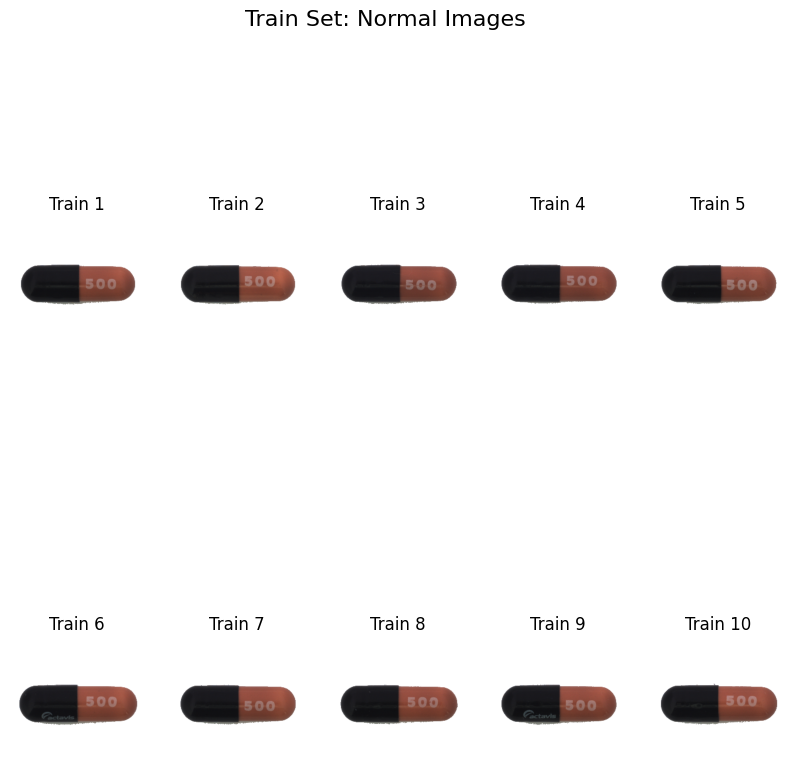

In [7]:
# แสดงตัวอย่าง 10 ภาพจากชุดข้อมูล train (ภาพปกติ)
plt.figure(figsize=(10, 10))  
for i in range(10):
    plt.subplot(2, 5, i + 1)  
    plt.imshow(x_train[i])  
    plt.axis('off')  
    plt.title(f"Train {i+1}") 
plt.suptitle("Train Set: Normal Images", fontsize=16)  
plt.show()

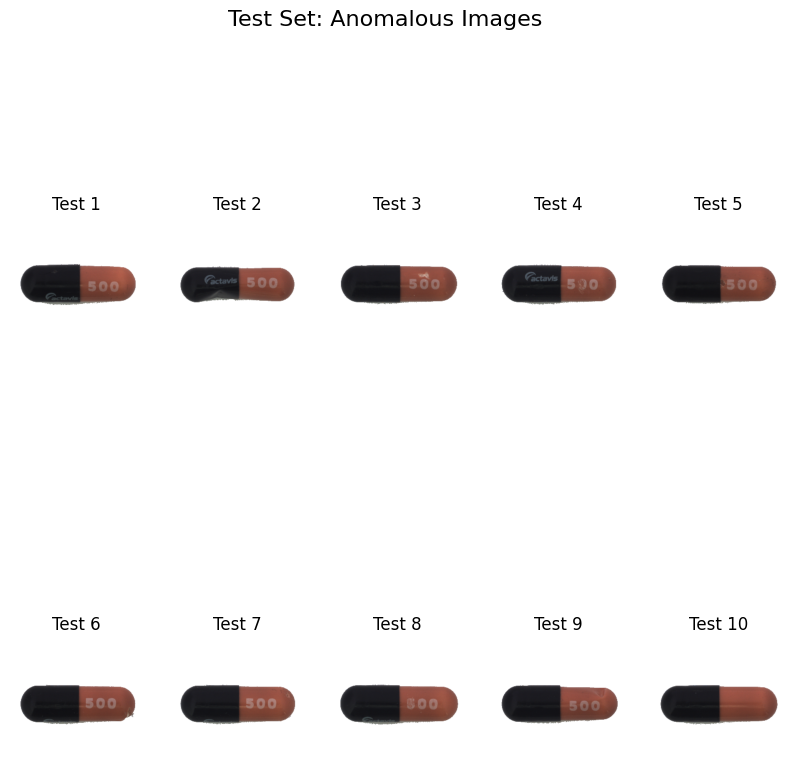

In [8]:
# แสดงตัวอย่าง 10 ภาพจากชุดข้อมูล test (ภาพที่ผิดปกติ)
plt.figure(figsize=(10, 10))  
for i in range(10):
    plt.subplot(2, 5, i + 1)  
    plt.imshow(x_test[i])  
    plt.axis('off')  
    plt.title(f"Test {i+1}")  
plt.suptitle("Test Set: Anomalous Images", fontsize=16) 
plt.show()

# Autoencoder

In [9]:
class Autoencoder(Model):
    def __init__(self, latent_dim, shape):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.shape = shape

        # Encoder: Flatten + Dense layers + Dropout 
        self.encoder = tf.keras.Sequential([
            layers.Flatten(),
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.1),  
            layers.Dense(16, activation='relu'),
            layers.Dropout(0.1),  
            layers.Dense(8, activation='relu'),
            layers.Dropout(0.1),  
            layers.Dense(latent_dim, activation='relu'),
            layers.Dropout(0.1),  
        ])

        # Decoder: Dense layers + Dropout + Reshape 
        self.decoder = tf.keras.Sequential([
            layers.Dense(8, activation='relu'),
            layers.Dropout(0.1),  
            layers.Dense(16, activation='relu'),
            layers.Dropout(0.1),  
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.1),  
            layers.Dense(tf.math.reduce_prod(shape).numpy(), activation='sigmoid'),
            layers.Reshape(shape)
        ])
        
    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

shape = (256, 256, 3)  # ขนาดของภาพ
latent_dim = 180  # ขนาดของ latent space

autoencoder = Autoencoder(latent_dim, shape)

In [10]:
autoencoder.compile(optimizer='adam', loss='mse')  

# K-Fold cross validation

Training fold 1...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 486ms/step - loss: 0.2152 - val_loss: 0.2121
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 0.2030 - val_loss: 0.1163
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - loss: 0.0846 - val_loss: 0.0064
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.0057 - val_loss: 0.0054
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - loss: 0.0050 - val_loss: 0.0049
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - lo

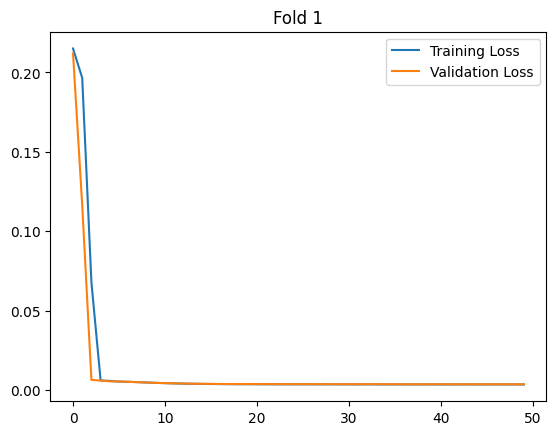

Training fold 2...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - loss: 0.2151 - val_loss: 0.2138
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 0.2065 - val_loss: 0.1292
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - loss: 0.0955 - val_loss: 0.0073
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - loss: 0.0061 - val_loss: 0.0058
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - loss: 0.0057 - val_loss: 0.0058
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - loss: 0.0053 - val_loss: 0.0051
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - loss: 0.0050 - val_loss: 0.0049
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - lo

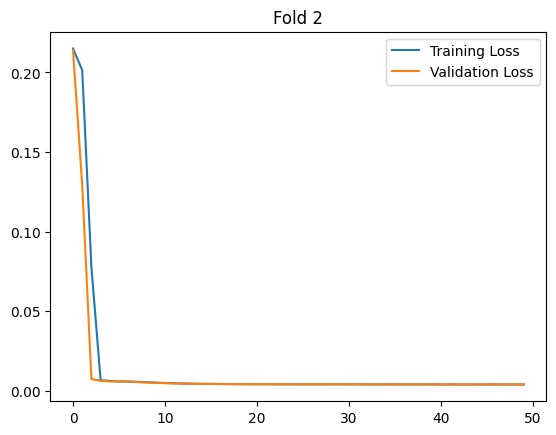

Training fold 3...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 356ms/step - loss: 0.2150 - val_loss: 0.2113
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - loss: 0.2008 - val_loss: 0.1202
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - loss: 0.0897 - val_loss: 0.0071
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - loss: 0.0051 - val_loss: 0.0048
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - lo

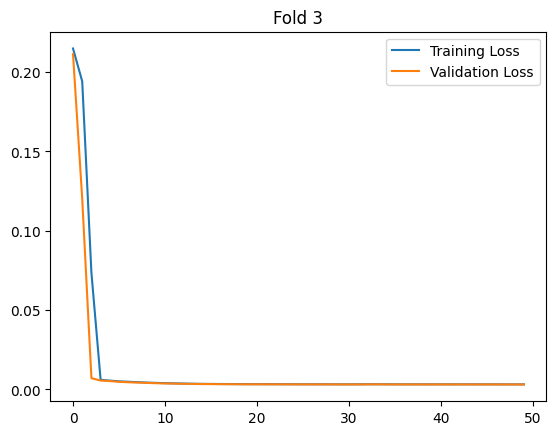

Training fold 4...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - loss: 0.2151 - val_loss: 0.2132
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 0.2047 - val_loss: 0.1216
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - loss: 0.0891 - val_loss: 0.0067
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - loss: 0.0062 - val_loss: 0.0058
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - loss: 0.0052 - val_loss: 0.0052
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - lo

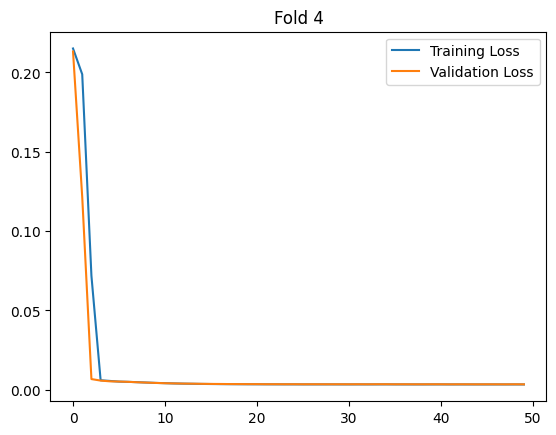

Training fold 5...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 336ms/step - loss: 0.2151 - val_loss: 0.2146
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - loss: 0.2122 - val_loss: 0.1753
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - loss: 0.1468 - val_loss: 0.0256
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - loss: 0.0175 - val_loss: 0.0059
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 0.0054 - val_loss: 0.0050
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 0.0051 - val_loss: 0.0048
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - lo

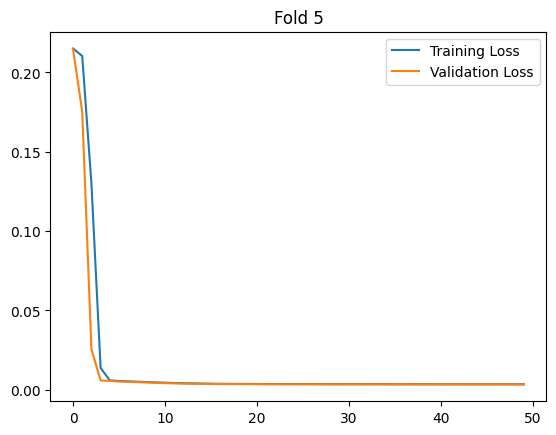

Average validation loss over 5 folds: 0.003465664107352495


In [12]:
shape = (256, 256, 3)  # ขนาดของภาพ
latent_dim = 180  # ขนาดของ latent space

# กำหนดจำนวน k folds
k = 5
kf = KFold(n_splits=k, shuffle=True)

# เก็บผลลัพธ์การฝึกในแต่ละ fold
fold_no = 1
results = []

x_train_np = x_train.numpy()

for train_index, val_index in kf.split(x_train_np):
    print(f"Training fold {fold_no}...")

    # แบ่งข้อมูลออกเป็น train และ validation sets
    x_train_fold, x_val_fold = x_train_np[train_index], x_train_np[val_index]

    x_train_fold = tf.convert_to_tensor(x_train_fold)
    x_val_fold = tf.convert_to_tensor(x_val_fold)

    # สร้างโมเดลใหม่ทุกครั้งที่เริ่ม fold ใหม่
    autoencoder = Autoencoder(latent_dim, shape)
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    # ฝึกโมเดล
    history = autoencoder.fit(x_train_fold, x_train_fold,  
                              epochs=50,
                              batch_size=64,
                              validation_data=(x_val_fold, x_val_fold),  
                              shuffle=True
                              )

    # Plot กราฟสำหรับแต่ละ fold
    plt.figure()  
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Fold {fold_no}")
    plt.legend()
    plt.show()  

    results.append(history.history)
    fold_no += 1

average_loss = np.mean([result['val_loss'][-1] for result in results])
print(f"Average validation loss over {k} folds: {average_loss}")

# Model

In [13]:
autoencoder = Autoencoder(latent_dim, shape)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# เพิ่ม Early Stopping callback
early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# ฝึกโมเดลพร้อมกับ Dropout และ Early Stopping
history = autoencoder.fit(x_train, x_train,
                          epochs=15,
                          batch_size=64,
                          shuffle=True,
                          callbacks=[early_stopping])

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - loss: 0.2150
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.1706
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0102
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.0058
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.0056
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0054
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.0051
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0047
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0045
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0043
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.0042
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0041
Epoch 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0040
Epoch 14/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.0040
Epoch 15/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0039


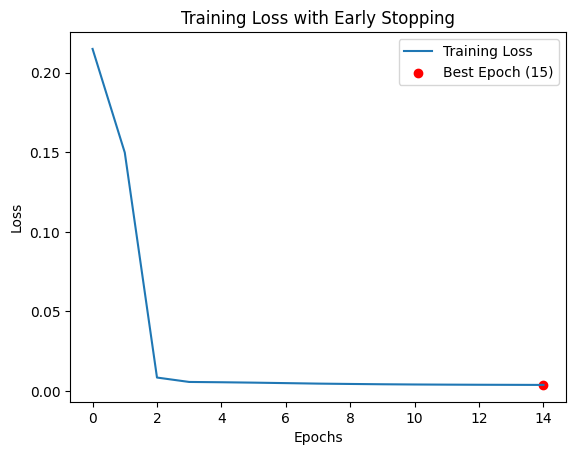

Early Stopping Callback weights ที่ epoch: 15 ด้วยค่า loss ที่ดีที่สุด: 0.0038850028067827225


In [14]:
# ค้นหา epoch ที่ได้ค่า loss ต่ำที่สุด
best_epoch = np.argmin(history.history['loss']) + 1  # บวก 1 เพราะ index เริ่มที่ 0
best_loss = history.history['loss'][best_epoch - 1]

# Plot Training Loss
plt.plot(history.history['loss'], label='Training Loss')

# Add a point for the best epoch
plt.scatter(best_epoch - 1, best_loss, color='red', label=f'Best Epoch ({best_epoch})')

# Add labels and legend
plt.title('Training Loss with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show plot
plt.show()

print(f"Early Stopping Callback weights ที่ epoch: {best_epoch} ด้วยค่า loss ที่ดีที่สุด: {best_loss}")

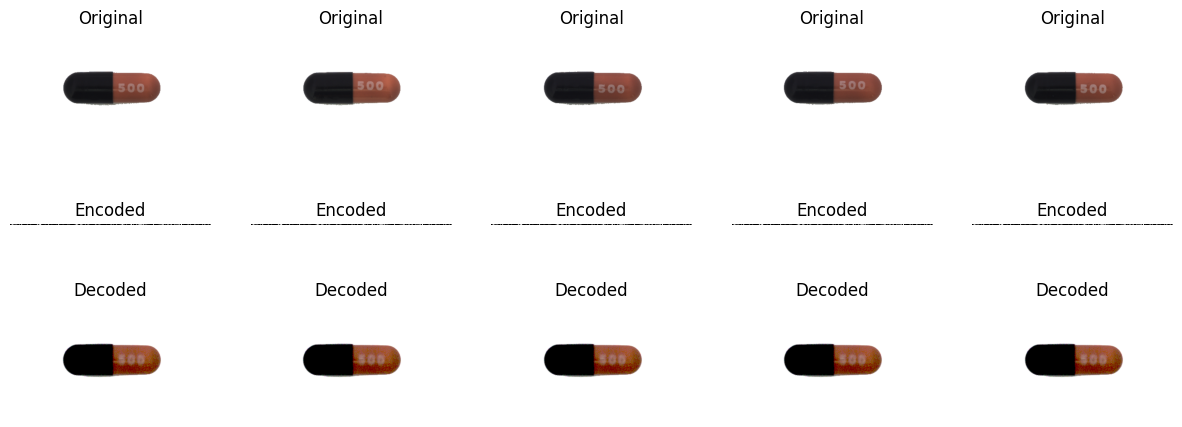

In [15]:
shapes = 256
encoded_data = autoencoder.encoder(x_train)  # เรียก encoder เพื่อสร้างข้อมูลที่ถูกบีบอัด
decoded_data = autoencoder.decoder(encoded_data)  # เรียก decoder เพื่อสร้างภาพที่ถูก reconstruct

# แสดงภาพต้นฉบับ, encoded data, และ decoded data
n = 5  # จำนวนภาพที่จะแสดง
plt.figure(figsize=(15, 5))

for i in range(n):
    # แสดงภาพต้นฉบับ
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_train[i].numpy())  
    plt.title("Original")
    plt.axis("off")

    # แสดง encoded data (ภาพที่ถูกบีบอัด)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_data[i].numpy().reshape(-1, encoded_data.shape[-1]), cmap='gray')  # Encoded data มักไม่ใช่ภาพ RGB
    plt.title("Encoded")
    plt.axis("off")

    # แสดง decoded data (ภาพที่สร้างใหม่)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_data[i].numpy())  
    plt.title("Decoded")
    plt.axis("off")

plt.show()

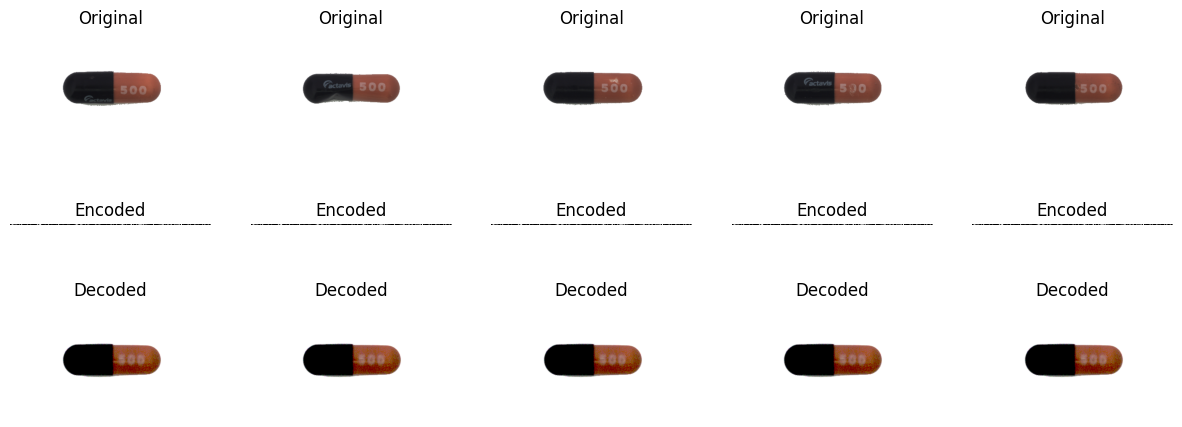

In [16]:
shapes = 256
encoded_data = autoencoder.encoder(x_test)  # เรียก encoder เพื่อสร้างข้อมูลที่ถูกบีบอัด
decoded_data = autoencoder.decoder(encoded_data)  # เรียก decoder เพื่อสร้างภาพที่ถูก reconstruct

# แสดงภาพต้นฉบับ, encoded data, และ decoded data
n = 5  # จำนวนภาพที่จะแสดง
plt.figure(figsize=(15, 5))

for i in range(n):
    # แสดงภาพต้นฉบับ
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].numpy())  
    plt.title("Original")
    plt.axis("off")

    # แสดง encoded data (ภาพที่ถูกบีบอัด)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_data[i].numpy().reshape(-1, encoded_data.shape[-1]), cmap='gray')  # Encoded data มักไม่ใช่ภาพ RGB
    plt.title("Encoded")
    plt.axis("off")

    # แสดง decoded data (ภาพที่สร้างใหม่)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_data[i].numpy())
    plt.title("Decoded")
    plt.axis("off")

plt.show()

# Detect anomalies

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
0.025895409751683474
จำนวนภาพที่ผิดปกติ: 7


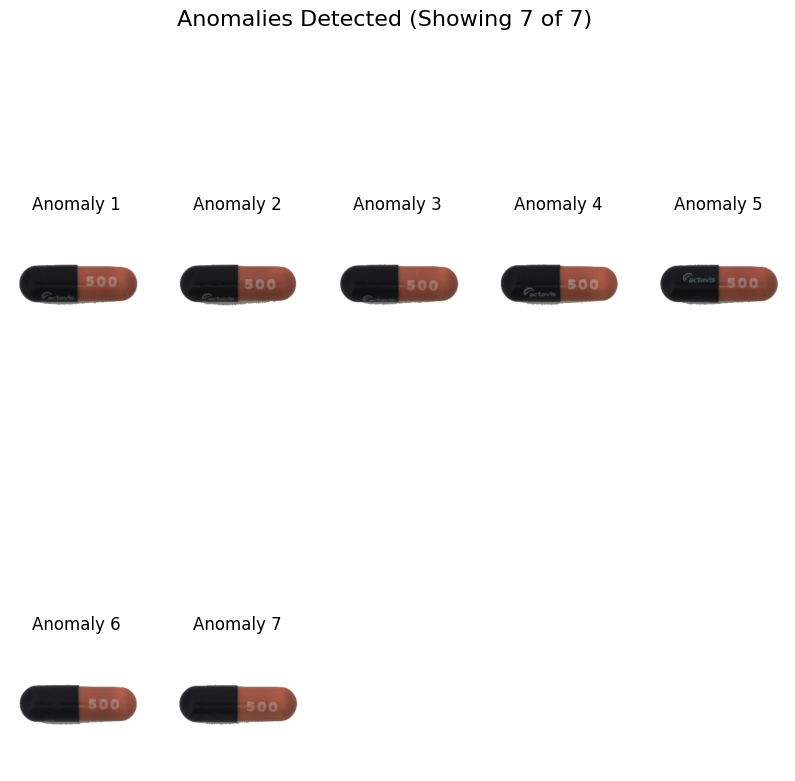

In [17]:
# สมมติว่า x_train คือภาพ capsule ที่ผิดปกติ (positive)
reconstructed = autoencoder.predict(x_train)

reconstruction_error = np.mean(np.abs(x_train - reconstructed), axis=(1, 2, 3))
mean_error = np.mean(reconstruction_error)
std_error = np.std(reconstruction_error)

# ค่า threshold คือค่าเฉลี่ยบวก 2 เท่าของค่าเบี่ยงเบนมาตรฐาน
threshold = mean_error + 2 * std_error
print(threshold)

# กำหนด threshold สำหรับ Anomaly Detection
anomalies = reconstruction_error > threshold

# แสดงผลลัพธ์ว่าภาพใดเป็น anomaly
print("จำนวนภาพที่ผิดปกติ:", np.sum(anomalies))

# แสดงภาพที่เป็น anomalies
n_anomalies = np.sum(anomalies)
plt.figure(figsize=(10, 10))
for i in range(min(n_anomalies, 10)):  
    index = np.where(anomalies)[0][i]  
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[index])  
    plt.title(f"Anomaly {i + 1}")
    plt.axis('off')
plt.suptitle(f"Anomalies Detected (Showing {min(n_anomalies, 10)} of {n_anomalies})", fontsize=16)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
0.031182948
จำนวนภาพที่ผิดปกติ: 15


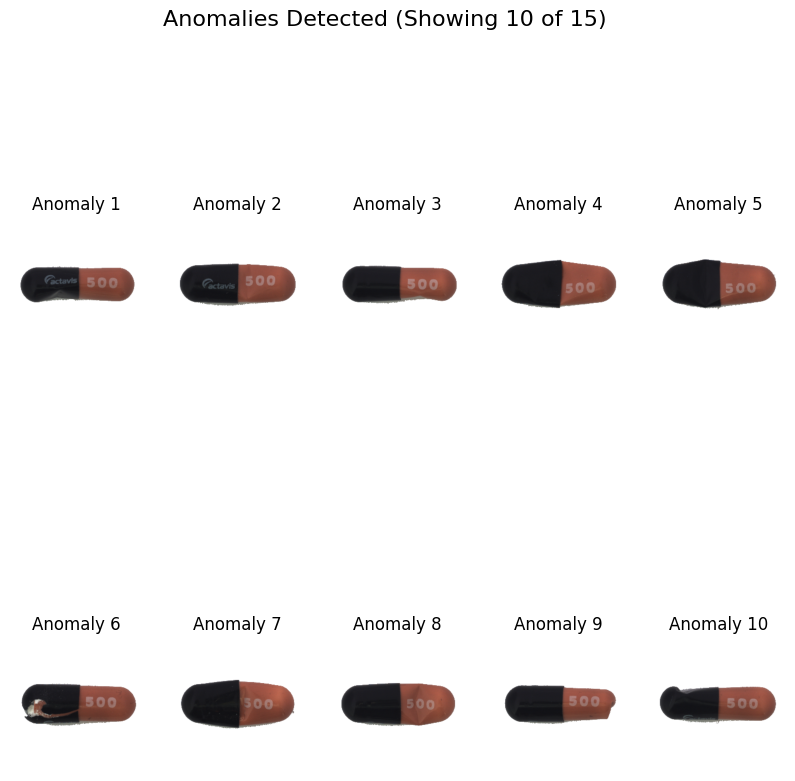

In [18]:
reconstructed = autoencoder.predict(x_test)

reconstruction_error = np.mean(np.abs(x_test - reconstructed), axis=(1, 2, 3))
mean_error = np.mean(reconstruction_error)
std_error = np.std(reconstruction_error)

# ค่า threshold คือค่าเฉลี่ยบวก 2 เท่าของค่าเบี่ยงเบนมาตรฐาน
threshold = mean_error + std_error
print(threshold)

# กำหนด threshold สำหรับ Anomaly Detection
anomalies = reconstruction_error > threshold

# แสดงผลลัพธ์ว่าภาพใดเป็น anomaly
print("จำนวนภาพที่ผิดปกติ:", np.sum(anomalies))

# แสดงภาพที่เป็น anomalies
n_anomalies = np.sum(anomalies)
plt.figure(figsize=(10, 10))
for i in range(min(n_anomalies, 10)):  # แสดงได้มากสุด 10 ภาพ
    index = np.where(anomalies)[0][i]  # หาค่าดัชนีที่เป็น anomaly
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index])  # แสดงภาพที่เป็น anomaly
    plt.title(f"Anomaly {i + 1}")
    plt.axis('off')
plt.suptitle(f"Anomalies Detected (Showing {min(n_anomalies, 10)} of {n_anomalies})", fontsize=16)
plt.show()

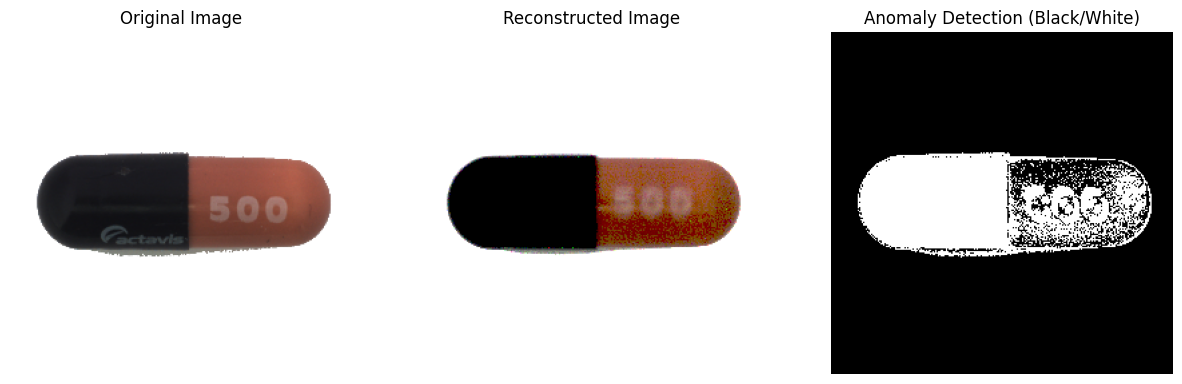

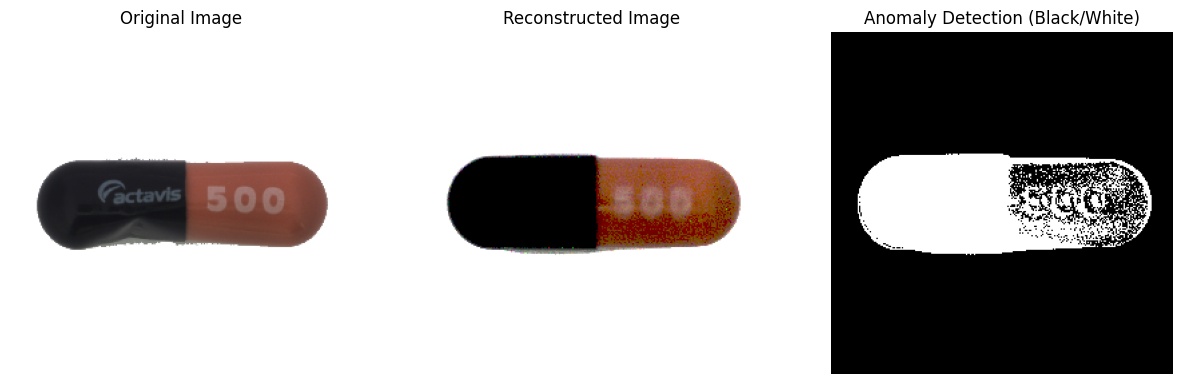

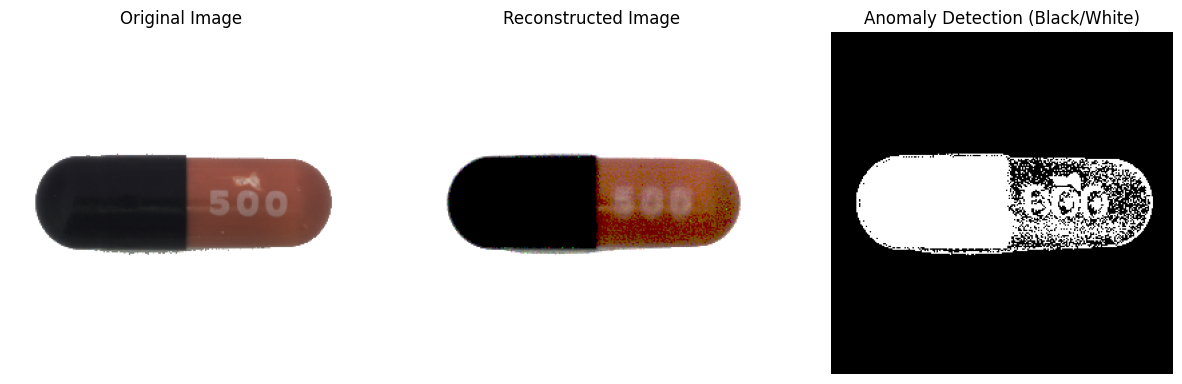

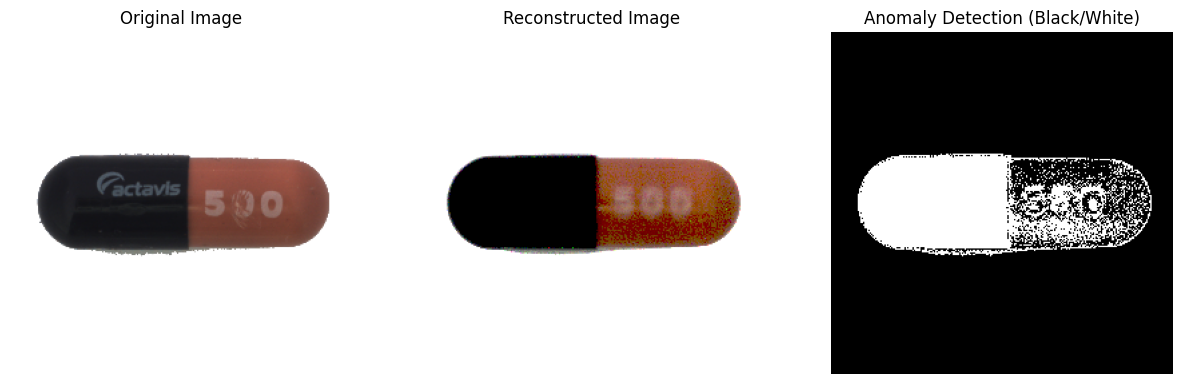

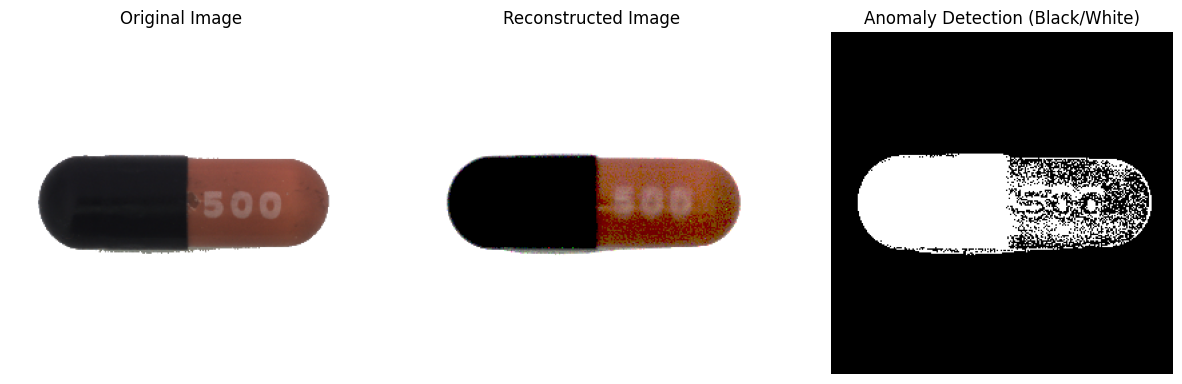

In [20]:
x_test_gray = tf.image.rgb_to_grayscale(x_test)
reconstructed_gray = tf.image.rgb_to_grayscale(reconstructed)

# คำนวณความแตกต่างระหว่างภาพต้นฉบับและภาพที่สร้างใหม่ (error map)
error_map = np.abs(x_test_gray - reconstructed_gray)

# สร้าง mask สำหรับพิกเซลที่มี error สูงกว่า threshold
anomaly_mask = error_map > threshold  # เทียบทุกพิกเซลกับ threshold โดยตรง

# วาดภาพต้นฉบับ, ภาพที่ reconstruct, และ mask ที่แสดงส่วนผิดปกติ
for i in range(5):  # แสดง 5 ตัวอย่าง
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # แสดงภาพต้นฉบับ
    ax[0].imshow(x_test[i])
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    # แสดงภาพที่โมเดลสร้างขึ้นใหม่ (Reconstructed Image)
    ax[1].imshow(reconstructed[i].squeeze())  # แสดงภาพที่ reconstruct
    ax[1].set_title("Reconstructed Image")
    ax[1].axis("off")

    # แสดง mask ที่แสดงจุดที่ผิดปกติ (เป็นสีขาว)
    anomaly_overlay = np.zeros_like(x_test_gray[i])  # สร้างภาพสีดำ
    anomaly_overlay[anomaly_mask[i]] = 1  # ทำให้จุดที่เป็น anomaly เป็นสีขาว
    ax[2].imshow(anomaly_overlay.squeeze(), cmap='gray', vmin=0, vmax=1)  # บังคับให้ใช้ grayscale ในช่วง 0-1
    ax[2].set_title("Anomaly Detection (Black/White)")
    ax[2].axis("off")

    plt.show()